# Week 4 实验报告 — BSM 基线模型性能评估

## 按 Week 4 三大任务组织

**任务一：误差指标计算** — 计算 BSM 模型预测值与实际交易价格之间的 MAE/RMSE

**任务二：局限性分析** — 识别高波动期失效模式及情绪影响缺口

**任务三：基准建立** — 记录 BSM 模型性能基线以供比较

In [1]:
# ============================================================
# 导入依赖
# ============================================================
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

# Week3 pricer
WEEK3 = Path(r'E:\实习交付\week2\week3')
if str(WEEK3) not in sys.path: sys.path.insert(0, str(WEEK3))
from chooser_option_pricer import bs_call, bs_put, simple_chooser, simple_chooser_mc, simple_chooser_decomposed

# Week4 modules
sys.path.insert(0, r'E:\实习交付\week2\week4')
from bsm_evaluation import (convergence_analysis, compute_all_greeks,
    parameter_impact_analysis, classify_market_regime, full_bsm_assessment, load_week3_data)
from bsm_market_validation import (get_current_market_params, fetch_option_chain,
    compute_bsm_vs_market, compute_implied_volatilities, compute_error_metrics)

print('All dependencies loaded.')

All dependencies loaded.


---
# 任务一：误差指标计算

计算 BSM 模型预测值与真实市场交易价格之间的 MAE、RMSE、MAPE。
由于 Chooser Option 是 OTC 奇异期权，使用 JPM 普通期权（vanilla call/put）的真实交易数据进行替代验证。

## 1.1 BSM 定价模型实现

基于 Rubinstein (1991) 的 Simple Chooser Option 定价公式：
$$V = Se^{-qT_2}[N(d_1) - N(-d_3)] - Ke^{-rT_2}[N(d_2) - N(-d_4)]$$

In [2]:
# ============================================================
# BSM 核心定价函数（直接引用 week3 实现）
# ============================================================

# Simple Chooser Option 快速演示
S, K, t1, T2, r, q, sigma = 100, 100, 0.25, 1.0, 0.08, 0.0, 0.20
p = simple_chooser(S, K, t1, T2, r, q, sigma)
c = bs_call(S, K, T2, r, q, sigma)
pt = bs_put(S, K, T2, r, q, sigma)

print(f'S={S}, K={K}, t1={t1}, T2={T2}, r={r}, q={q}, sigma={sigma}')
print(f'  BS Call:              ${c:.2f}')
print(f'  BS Put:               ${pt:.2f}')
print(f'  Chooser (Analytic):   ${p:.2f}')
print(f'  Max(C,P) [t1=0]:      ${max(c,pt):.2f}')
print(f'  C+P [t1=T2]:          ${c+pt:.2f}')
print(f'  Analytic vs MC bias:  {abs(p-float(simple_chooser_mc(S,K,t1,T2,r,q,sigma)[0]))/p*100:.3f}%')

S=100, K=100, t1=0.25, T2=1.0, r=0.08, q=0.0, sigma=0.2
  BS Call:              $12.11
  BS Put:               $4.42
  Chooser (Analytic):   $13.26
  Max(C,P) [t1=0]:      $12.11
  C+P [t1=T2]:          $16.52
  Analytic vs MC bias:  0.044%


## 1.2 实盘市场验证：MAE/RMSE 计算

获取 JPM 期权链真实交易数据，计算 BSM(vol_21d) 与市场价格的偏差。

In [3]:
# ============================================================
# 获取市场参数与期权数据
# ============================================================

params = get_current_market_params()
S, r, q, sigma_hv = params['S'], params['r'], params['q'], params['vol_21d']

print('当前市场参数:')
print(f'  JPM 股价 (S):           ${S:.2f}')
print(f'  无风险利率 (r):          {r*100:.2f}%')
print(f'  股息率 (q):             {q*100:.2f}%')
print(f'  历史波动率 vol_21d:      {sigma_hv*100:.1f}%')

options = fetch_option_chain('JPM')
results = compute_bsm_vs_market(options, S, r, q, sigma_hv)
results = compute_implied_volatilities(results, S, r, q)
results['vol_error'] = results['implied_vol'] - sigma_hv

print(f'\n期权数据: {len(results)} 个合约 ({results["type"].value_counts().to_dict()})')
print(f'到期日: {results["expiry"].nunique()} 个, 期限: {results["T"].min():.2f}-{results["T"].max():.2f} 年')

当前市场参数:
  JPM 股价 (S):           $353.21
  无风险利率 (r):          3.81%
  股息率 (q):             1.70%
  历史波动率 vol_21d:      20.2%



期权数据: 595 个合约 ({'call': 316, 'put': 279})
到期日: 6 个, 期限: 0.10-0.47 年


In [4]:
# ============================================================
# MAE/RMSE 误差指标
# ============================================================

metrics = compute_error_metrics(results)

print('='*65)
print('BSM vs 市场：MAE/RMSE 误差指标')
print('='*65)
table = metrics[['group','count','MAE','RMSE','MAPE','MeanBiasPct']].copy()
table.columns = ['Group','Count','MAE($)','RMSE($)','MAPE(%)','Bias(%)']
print(table.to_string(index=False))
print()

# 按货币度细分
for label, mask in [
    ('ATM+OTM (all OTM)', results['moneyness'] != 'ITM'),
    ('ATM only (|log-mny|<5%)', abs(results['log_moneyness']) < 0.05),
    ('OTM Calls', (results['type']=='call') & (results['moneyness']=='OTM')),
    ('OTM Puts', (results['type']=='put') & (results['moneyness']=='OTM')),
]:
    sub = results[mask]
    if len(sub) == 0: continue
    ivp = (sub['implied_vol'].mean() - sigma_hv) * 100
    print(f'  {label:>25s}: n={len(sub):>3d}  MAE=${sub["abs_error"].mean():>7.4f}  '
          f'RMSE=${np.sqrt(sub["squared_error"].mean()):>7.4f}  '
          f'Bias={sub["bias_pct"].mean():>6.1f}%  IV_Pr={ivp:>5.1f}%')

atm = results[abs(results['log_moneyness']) < 0.05]
print(f'\n核心发现: ATM IV={atm["implied_vol"].mean()*100:.1f}% vs vol_21d={sigma_hv*100:.1f}%')
print(f'            OTM 看跌 IV 最高 {results[results["type"]=="put"]["implied_vol"].max()*100:.1f}%（波动率微笑）')

BSM vs 市场：MAE/RMSE 误差指标
Group  Count    MAE($)   RMSE($)   MAPE(%)    Bias(%)
  ALL    595  7.464468 15.167686 46.024124 -35.519121
 CALL    316  9.305212 17.183562 23.917401  -4.137410
  PUT    279  5.379610 12.497753 71.062564 -71.062564
  ITM    272 14.621343 22.316130 15.769829   0.293618
  OTM    323  1.437625  2.101374 71.501426 -65.677216
  <3m    250  6.244765 12.964832 43.495663 -36.518512
 3-6m    345  8.348310 16.582093 47.856343 -34.794924

          ATM+OTM (all OTM): n=323  MAE=$ 1.4376  RMSE=$ 2.1014  Bias= -65.7%  IV_Pr= 15.7%
    ATM only (|log-mny|<5%): n= 76  MAE=$ 3.5201  RMSE=$ 4.0715  Bias= -19.6%  IV_Pr=  4.9%
                  OTM Calls: n=109  MAE=$ 1.2608  RMSE=$ 1.7451  Bias= -27.6%  IV_Pr=  3.3%
                   OTM Puts: n=214  MAE=$ 1.5277  RMSE=$ 2.2614  Bias= -85.1%  IV_Pr= 22.0%

核心发现: ATM IV=25.2% vs vol_21d=20.2%
            OTM 看跌 IV 最高 130.8%（波动率微笑）


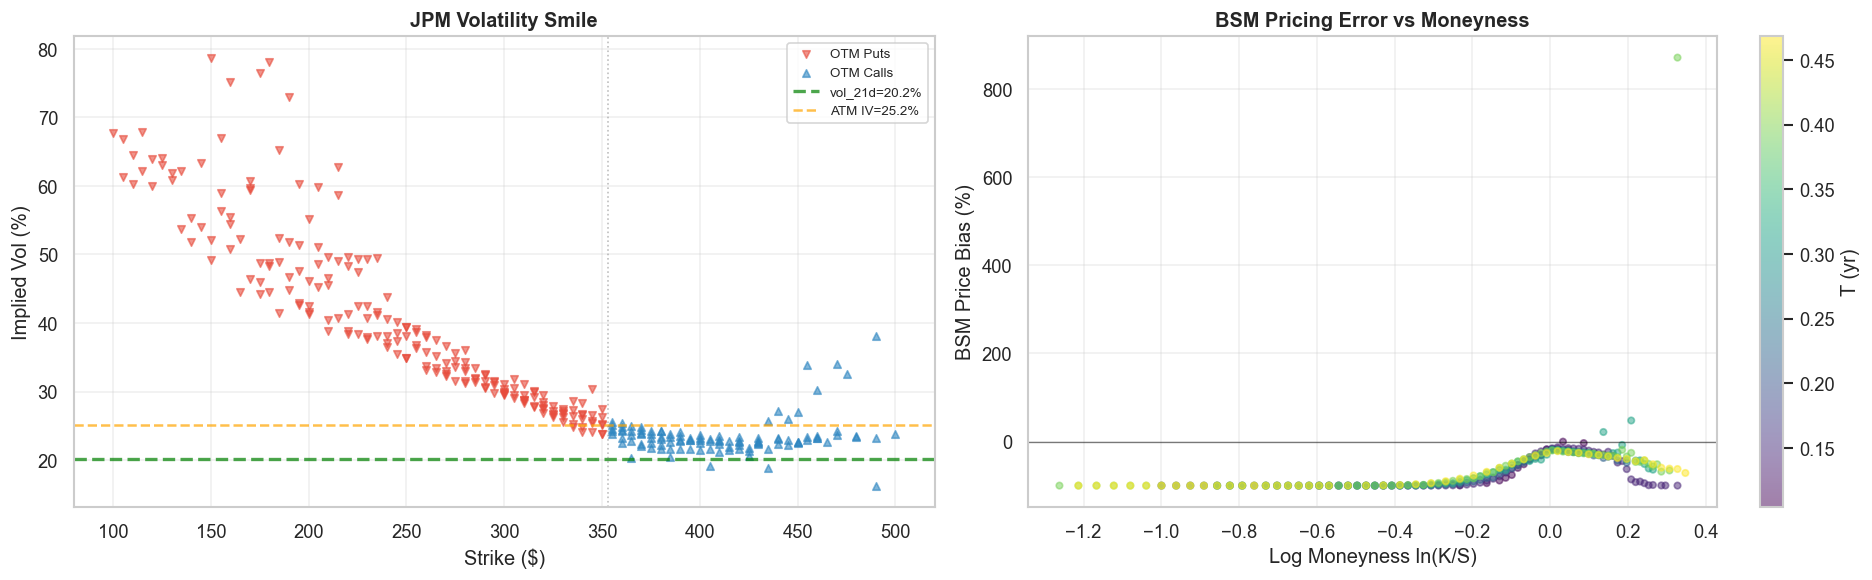

In [5]:
# ============================================================
# 波动率微笑可视化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

otm_puts = results[(results['type']=='put') & (results['moneyness']=='OTM') & (results['implied_vol']<0.80)]
otm_calls = results[(results['type']=='call') & (results['moneyness']=='OTM') & (results['implied_vol']<0.80)]

ax = axes[0]
ax.scatter(otm_puts['strike'], otm_puts['implied_vol']*100, alpha=0.6, s=20, c='#E74C3C', label='OTM Puts', marker='v')
ax.scatter(otm_calls['strike'], otm_calls['implied_vol']*100, alpha=0.6, s=20, c='#2E86C1', label='OTM Calls', marker='^')
ax.axhline(y=sigma_hv*100, color='green', ls='--', lw=2, alpha=0.7, label=f'vol_21d={sigma_hv*100:.1f}%')
ax.axhline(y=atm['implied_vol'].mean()*100, color='orange', ls='--', lw=1.5, alpha=0.7, label=f'ATM IV={atm["implied_vol"].mean()*100:.1f}%')
ax.axvline(x=S, color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Strike ($)'); ax.set_ylabel('Implied Vol (%)')
ax.set_title('JPM Volatility Smile', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
all_otm = results[results['moneyness']=='OTM']
sc = ax.scatter(all_otm['log_moneyness'], all_otm['bias_pct'], alpha=0.5, s=15, c=all_otm['T'], cmap='viridis')
plt.colorbar(sc, ax=ax, label='T (yr)')
ax.axhline(y=0, color='black', ls='-', lw=0.8, alpha=0.5)
ax.set_xlabel('Log Moneyness ln(K/S)'); ax.set_ylabel('BSM Price Bias (%)')
ax.set_title('BSM Pricing Error vs Moneyness', fontweight='bold'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/fig_4_10_volatility_smile.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 数值精度验证（解析解 vs MC）

验证 Rubinstein 解析公式自身的数值精度，作为误差指标的补充。

In [6]:
# ============================================================
# 收敛性分析
# ============================================================

conv = convergence_analysis(n_trials=5)
print(f"{'n_sims':>8s}  {'MAE':>10s}  {'RMSE':>10s}  {'Bias%':>10s}")
print('  ' + '-'*42)
for _, row in conv.iterrows():
    print(f"  {int(row['n_sims']):>8,d}  ${row['mae']:>8.4f}  ${row['rmse']:>8.4f}  {row['mean_bias_pct']:>8.3f}%")
print(f"\n收敛速率 beta = {conv['convergence_rate_beta'].iloc[0]:.3f} (理论 -0.5)")

  n_sims         MAE        RMSE       Bias%
  ------------------------------------------
     1,000  $  0.0488  $  0.0488    -0.368%
     5,000  $  0.0142  $  0.0142     0.107%
    10,000  $  0.0046  $  0.0046     0.035%
    50,000  $  0.0010  $  0.0010    -0.008%
   100,000  $  0.0092  $  0.0092     0.069%
   200,000  $  0.0059  $  0.0059     0.044%
   500,000  $  0.0047  $  0.0047    -0.036%

收敛速率 beta = -0.325 (理论 -0.5)


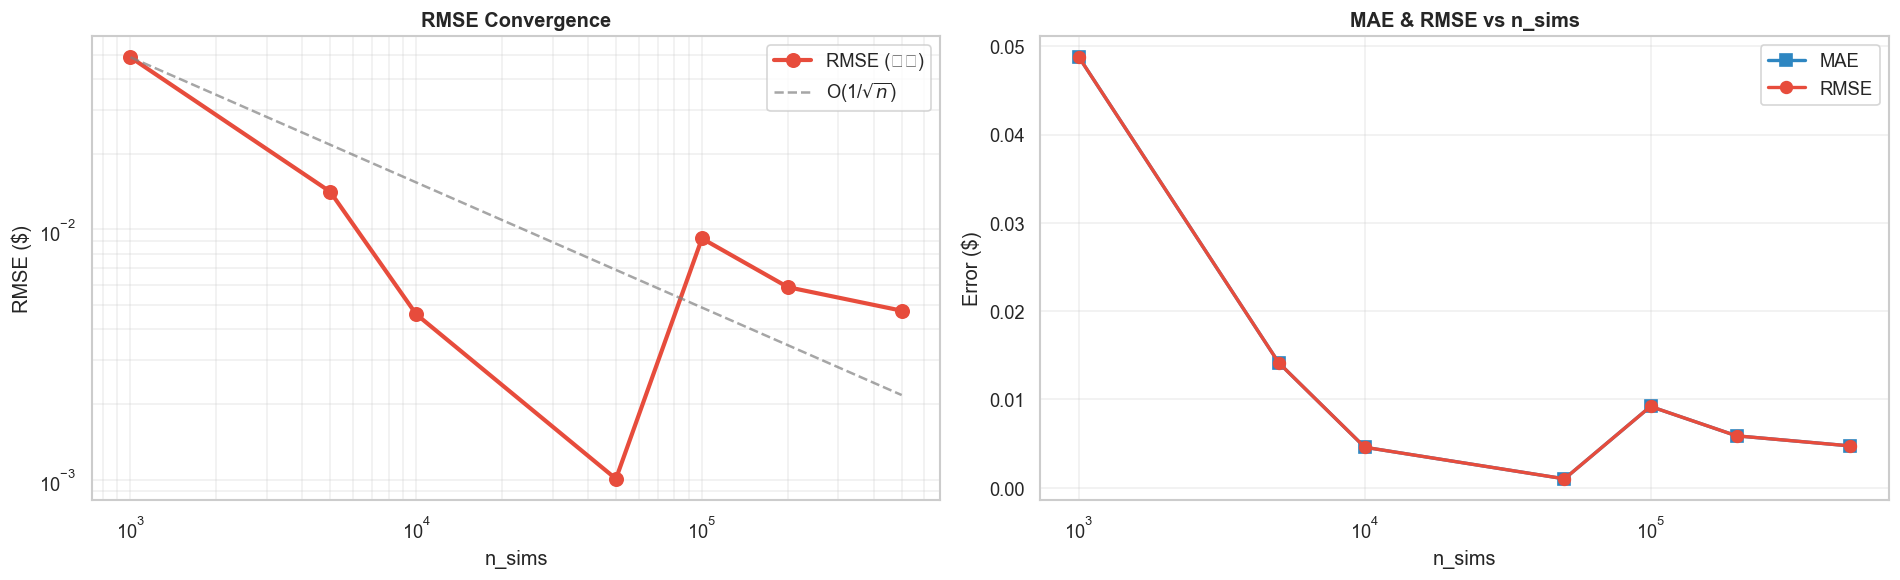

In [7]:
# ============================================================
# 收敛性可视化 & 参数空间精度
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.loglog(conv['n_sims'], conv['rmse'], 'o-', color='#E74C3C', lw=2.5, ms=8, label='RMSE (实测)')
n_vals = conv['n_sims'].values
ax.loglog(n_vals, conv['rmse'].iloc[0]*(n_vals[0]/n_vals)**0.5, '--', color='gray', lw=1.5, alpha=0.7, label=r'O(1/$\sqrt{n}$)')
ax.set_xlabel('n_sims'); ax.set_ylabel('RMSE ($)'); ax.set_title('RMSE Convergence', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.semilogx(conv['n_sims'], conv['mae'], 's-', color='#2E86C1', lw=2, ms=7, label='MAE')
ax.semilogx(conv['n_sims'], conv['rmse'], 'o-', color='#E74C3C', lw=2, ms=7, label='RMSE')
ax.set_xlabel('n_sims'); ax.set_ylabel('Error ($)'); ax.set_title('MAE & RMSE vs n_sims', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('assets/fig_4_1_convergence.png', dpi=150, bbox_inches='tight'); plt.show()

## 1.4 Greeks 风险度量

In [8]:
# ============================================================
# Greeks 计算
# ============================================================

paper = {'S':156.7, 'K':150.0, 't1':0.5, 'T2':1.0, 'r':0.0015, 'q':0.0233, 'sigma':0.282}
g = compute_all_greeks(**paper)
print(f"{'Greek':>12s}  {'Value':>12s}  {'Interpretation'}")
print('  ' + '-'*50)
print(f"{'Price':>12s}  ${simple_chooser(**paper):>9.2f}  {'Chooser option premium'}")
print(f"{'Delta':>12s}  {g['delta']:>11.4f}  {'Price sensitivity to S'}")
print(f"{'Gamma':>12s}  {g['gamma']:>11.6f}  {'Delta convexity'}")
print(f"{'Vega':>12s}  {g['vega']:>11.2f}  {'Price sensitivity to vol (+1%→+$'+str(g['vega']/100)[:4]+')'}")
print(f"{'Rho':>12s}  {g['rho']:>11.4f}  {'Price sensitivity to rate'}")
print(f"{'Theta':>12s}  {g['theta_t1']:>11.4f}  {'Time sensitivity (t1 delay)'}")

       Greek         Value  Interpretation
  --------------------------------------------------
       Price  $    29.13  Chooser option premium
       Delta       0.1656  Price sensitivity to S
       Gamma     0.020814  Delta convexity
        Vega       101.88  Price sensitivity to vol (+1%→+$1.01)
         Rho      -3.1783  Price sensitivity to rate
       Theta      11.9141  Time sensitivity (t1 delay)


## 1.5 参数敏感性分析

In [9]:
# ============================================================
# Tornado 敏感性分析
# ============================================================

impact = parameter_impact_analysis(shock_pct=10)
print(f"{'Param':>8s}  {'Base':>8s}  {'Price Low':>10s}  {'Price High':>10s}  {'Range':>8s}")
print('  ' + '-'*50)
for _, row in impact.iterrows():
    print(f"  {row['param']:>8s}  {row['base_value']:>8.3f}  ${row['price_low']:>8.2f}  ${row['price_high']:>8.2f}  ${row['price_range']:>7.2f}")
print('\n排序: 波动率 > 股价 > 选择日 > 行权价 > 股息率 > 利率')

   Param      Base   Price Low  Price High     Range
  --------------------------------------------------
         S   156.700  $   29.22  $   34.09  $   4.87
     sigma     0.282  $   26.26  $   32.00  $   5.75
         r     0.002  $   29.13  $   29.13  $   0.00
         q     0.023  $   29.19  $   29.07  $   0.12
        t1     0.500  $   28.52  $   29.71  $   1.19
         K   150.000  $   31.42  $   31.88  $   0.46

排序: 波动率 > 股价 > 选择日 > 行权价 > 股息率 > 利率


---
# 任务二：局限性分析

识别高波动期 BSM 的失效模式，量化情绪因子对定价缺口的影响，检验 BSM 核心假设。

## 2.1 市场 Regime 分类与高波动期失效模式

In [10]:
# ============================================================
# 加载历史数据并分类市场 Regime
# ============================================================

df = load_week3_data()
df['regime'] = classify_market_regime(df)

print(f'数据: {len(df)} 交易日 ({df["date"].min().date()} → {df["date"].max().date()})')
print(f'\nRegime 分布:')
for r, c in df['regime'].value_counts().items():
    print(f'  {r:>10s}: {c:>4d} 天 ({c/len(df)*100:.1f}%)')

print(f'\n各 Regime 特征:')
print(f'{"Regime":>12s}  {"Mean S":>8s}  {"Mean Vol":>8s}  {"Sentiment":>10s}')
for r in ['BULL','BEAR','HIGH_VOL','CALM','NORMAL']:
    sub = df[df['regime']==r]
    if len(sub)==0: continue
    print(f'  {r:>10s}  ${sub["close_jpm"].mean():>6.1f}  {sub["vol_21d"].mean()*100:>6.1f}%  {sub["sentiment_score"].mean():>8.3f}')

数据: 1755 交易日 (2018-01-09 → 2024-12-30)

Regime 分布:
    HIGH_VOL:  435 天 (24.8%)
        CALM:  429 天 (24.4%)
        BULL:  366 天 (20.9%)
      NORMAL:  345 天 (19.7%)
        BEAR:  180 天 (10.3%)

各 Regime 特征:
      Regime    Mean S  Mean Vol   Sentiment
        BULL  $ 148.9    19.3%     0.829
        BEAR  $ 109.3    24.9%     0.523
    HIGH_VOL  $ 120.3    42.1%     0.437
        CALM  $ 150.8    13.0%     0.860
      NORMAL  $ 144.2    23.1%     0.700


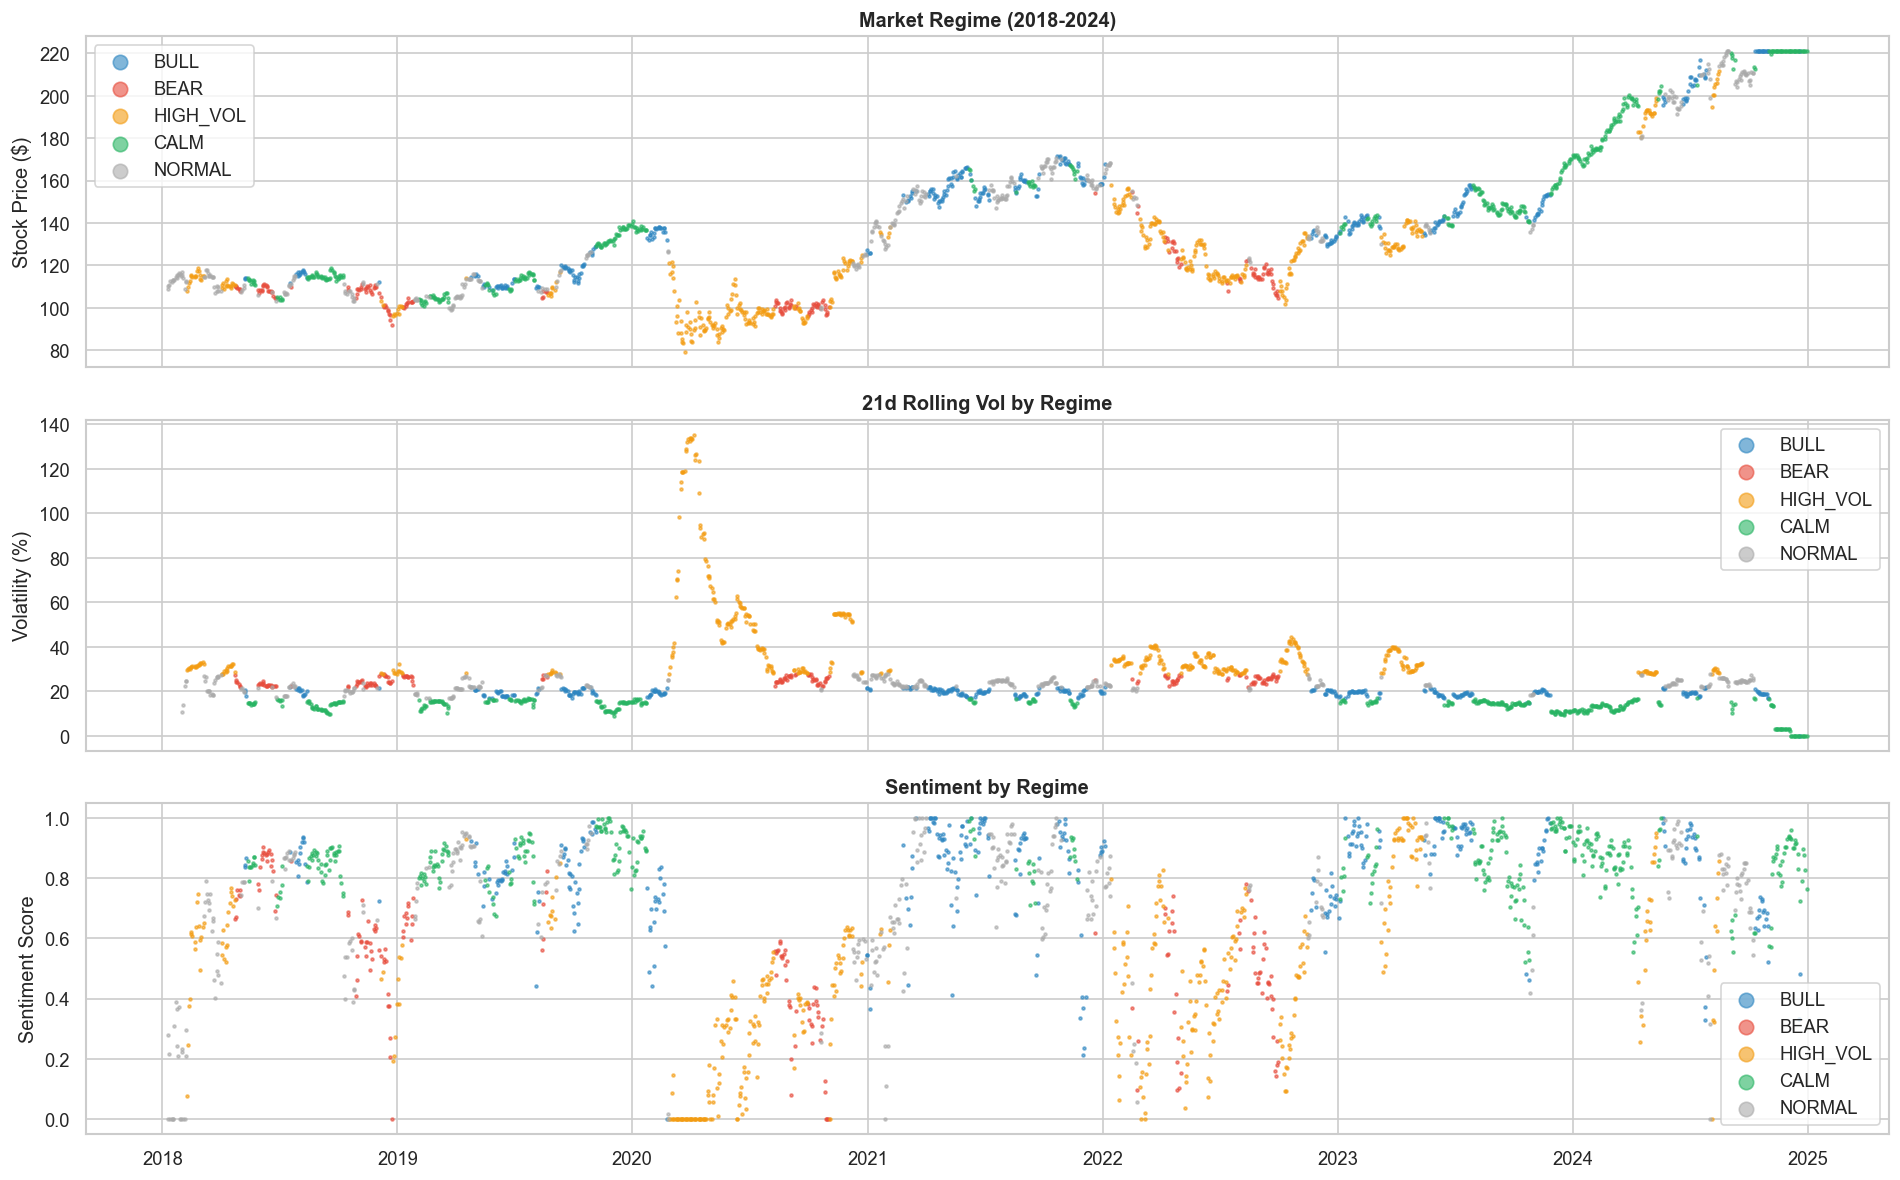

In [11]:
# ============================================================
# Regime 可视化
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
colors = {'BULL':'#2E86C1','BEAR':'#E74C3C','HIGH_VOL':'#F39C12','CALM':'#28B463','NORMAL':'#AAAAAA'}

for ax, (col, ylab, title) in zip(axes,
    [('close_jpm','Stock Price ($)','Market Regime (2018-2024)'),
     ('vol_21d','Volatility (%)','21d Rolling Vol by Regime'),
     ('sentiment_score','Sentiment Score','Sentiment by Regime')]):
    for r, c in colors.items():
        mask = df['regime']==r
        val = df.loc[mask, col] * (100 if col=='vol_21d' else 1)
        ax.scatter(df.loc[mask,'date'], val, c=c, s=3, alpha=0.6, label=r)
    ax.set_ylabel(ylab); ax.set_title(title, fontweight='bold'); ax.legend(markerscale=5)
plt.tight_layout(); plt.savefig('assets/fig_4_7_regime_classification.png', dpi=150, bbox_inches='tight'); plt.show()

In [12]:
# ============================================================
# Regime 误差分布
# ============================================================

K_FIXED, T2_FIXED, T1_FIXED = 150.0, 1.0, 0.5
regime_errors = []
for _, row in df.iterrows():
    S, r_v, q_v, sig = row['close_jpm'], row['value_treasury_3mo']/100, row['dividend_yield'], row['vol_21d']
    if np.isnan(sig) or sig<=0: continue
    a = simple_chooser(S, K_FIXED, T1_FIXED, T2_FIXED, r_v, q_v, sig)
    mc, _ = simple_chooser_mc(S, K_FIXED, T1_FIXED, T2_FIXED, r_v, q_v, sig, n_sims=50000)
    regime_errors.append({'regime':row['regime'], 'analytic':float(a), 'mc_price':float(mc),
                          'abs_error':float(abs(mc-a)), 'bias_pct':float((mc-a)/max(a,1e-8)*100)})
df_err = pd.DataFrame(regime_errors)

print(f"{'Regime':>12s}  {'Count':>6s}  {'MAE':>10s}  {'Max|E|':>10s}  {'Bias%':>10s}")
print('  '+'-'*50)
for r in ['BULL','BEAR','HIGH_VOL','CALM','NORMAL']:
    sub = df_err[df_err['regime']==r]
    if len(sub)==0: continue
    print(f'  {r:>10s}  {len(sub):>5d}  ${sub["abs_error"].mean():>7.4f}  ${sub["abs_error"].max():>7.4f}  {sub["bias_pct"].mean():>8.3f}%')

      Regime   Count         MAE      Max|E|       Bias%
  --------------------------------------------------
        BULL    364  $ 0.0026  $ 0.0099    -0.002%
        BEAR    180  $ 0.0043  $ 0.0094    -0.010%
    HIGH_VOL    435  $ 0.0186  $ 0.1795    -0.027%
        CALM    414  $ 0.0022  $ 0.0094     0.000%
      NORMAL    329  $ 0.0036  $ 0.0098    -0.006%


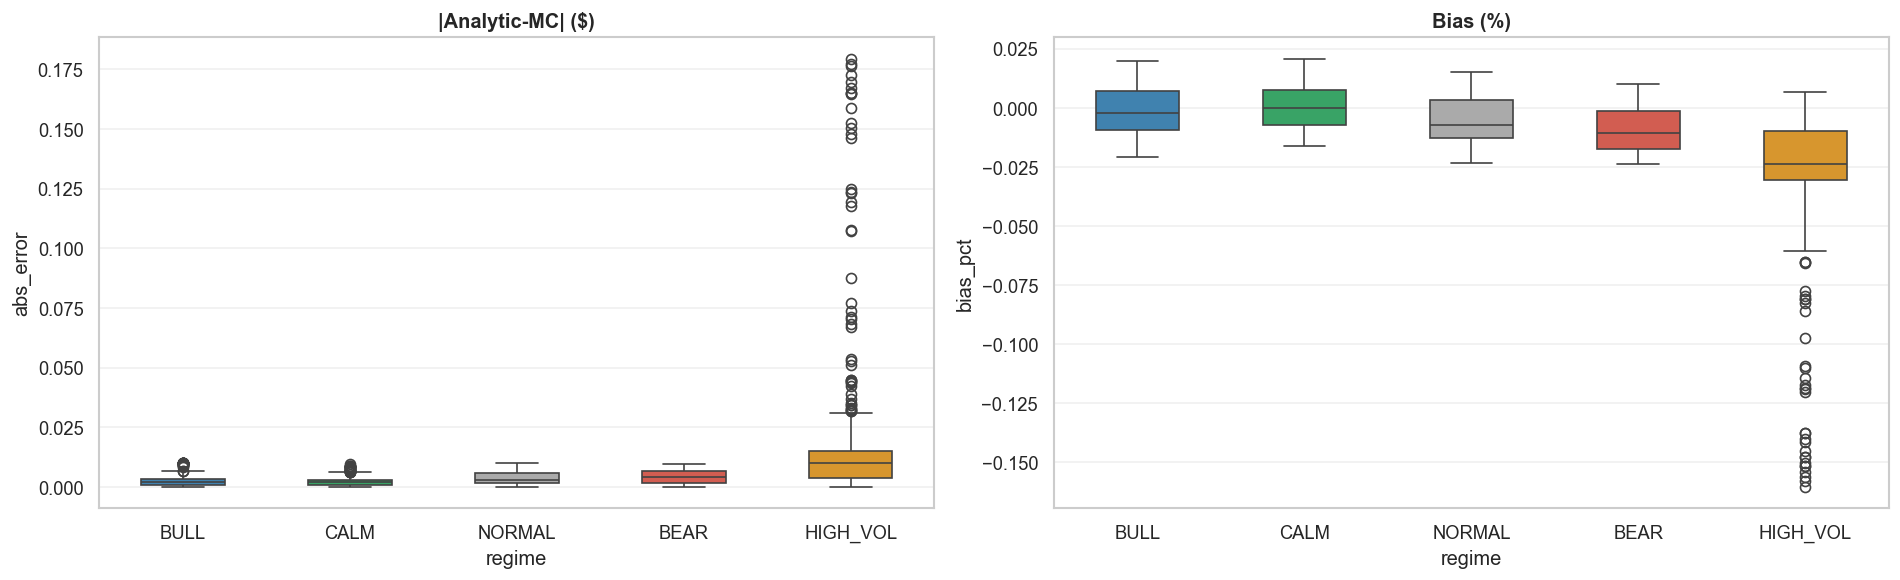

In [13]:
# ============================================================
# Regime 误差箱线图
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in [(axes[0],'abs_error','|Analytic-MC| ($)'), (axes[1],'bias_pct','Bias (%)')]:
    order = [r for r in ['BULL','CALM','NORMAL','BEAR','HIGH_VOL'] if r in df_err['regime'].values]
    sns.boxplot(x='regime', y=metric, data=df_err, order=order, palette=colors, ax=ax, width=0.5)
    ax.set_title(title, fontweight='bold'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('assets/fig_4_8_regime_error.png', dpi=150, bbox_inches='tight'); plt.show()

## 2.2 情绪影响缺口分析

In [14]:
# ============================================================
# 情绪 vs 波动率溢价
# ============================================================

print('情绪评分 vs 市场特征:')
print(f'{"Sentiment Range":>20s}  {"Days":>6s}  {"Mean Vol":>8s}  {"Vol Range":>14s}')
for lo, hi, lbl in [(0,0.25,'0.00-0.25'), (0.25,0.5,'0.25-0.50'),
                     (0.5,0.75,'0.50-0.75'), (0.75,1.0,'0.75-1.00')]:
    sub = df[(df['sentiment_score']>=lo) & (df['sentiment_score']<hi)]
    print(f'  {lbl:>18s}  {len(sub):>5d}  {sub["vol_21d"].mean()*100:>7.1f}%  '
          f'{sub["vol_21d"].min()*100:.0f}%-{sub["vol_21d"].max()*100:.0f}%')

print(f'\n结论：情绪评分<0.5时，波动率急剧上升。')
print(f'BSM模型无情绪机制，恐慌期使用vol_21d将严重低估实际波动率。')

情绪评分 vs 市场特征:
     Sentiment Range    Days  Mean Vol       Vol Range
           0.00-0.25    162     53.1%  11%-135%
           0.25-0.50    242     31.1%  0%-60%
           0.50-0.75    431     25.1%  0%-55%
           0.75-1.00    879     18.2%  0%-40%

结论：情绪评分<0.5时，波动率急剧上升。
BSM模型无情绪机制，恐慌期使用vol_21d将严重低估实际波动率。


## 2.3 BSM 假设诊断

In [15]:
# ============================================================
# BSM 五大假设检验
# ============================================================

assessment = full_bsm_assessment(df)
n, v, j = assessment['normality_test'], assessment['volatility_test'], assessment['jump_test']

print('BSM 假设诊断结果:')
print(f'  [正态性] JB p={n["jarque_bera_p"]:.4f}, 峰度={n["excess_kurtosis"]:.1f} → {"非正态" if not n["is_normal"] else "OK"}')
print(f'  [波动率] CV={v["cv"]:.2f}, 范围[{v["vol_min"]*100:.0f}%,{v["vol_max"]*100:.0f}%] → {"时变" if v["cv"]>0.5 else "稳定"}')
print(f'  [跳跃]   {j["n_jumps"]}/{j["n_obs"]}({j["jump_pct"]:.1f}%)日超{j["z_threshold"]}σ → {"有跳跃" if j["jump_pct"]>1 else "OK"}')
print(f'  [评分]   BSM 适用性: {assessment["bsm_suitability_score"]:.0f}/100 → {assessment["assessment"]}')

BSM 假设诊断结果:
  [正态性] JB p=0.0000, 峰度=13.7 → 非正态
  [波动率] CV=0.64, 范围[0%,135%] → 时变
  [跳跃]   25/1755(1.4%)日超3.0σ → 有跳跃
  [评分]   BSM 适用性: 37/100 → BSM assumptions are STRONGLY violated


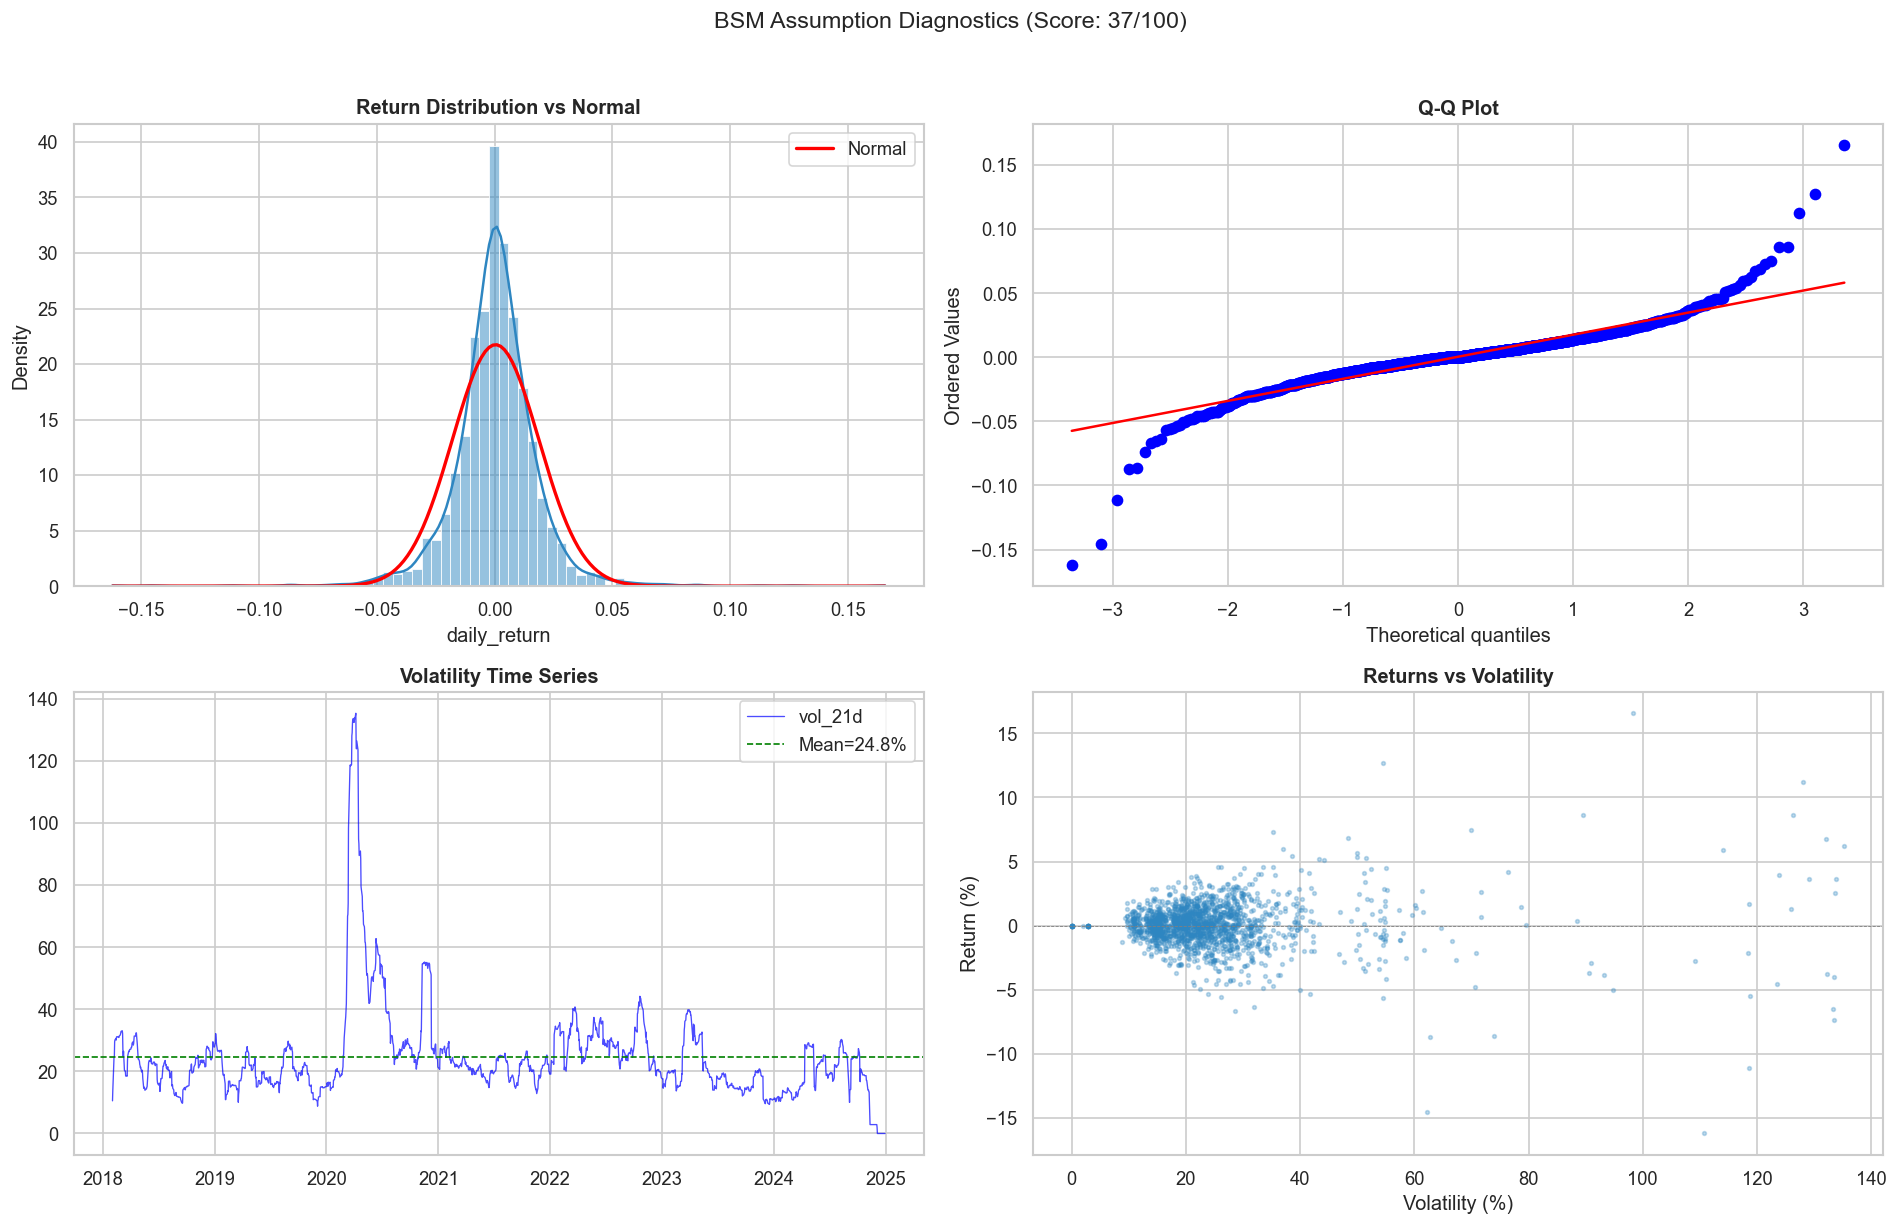

In [16]:
# ============================================================
# BSM 假设诊断可视化
# ============================================================

from scipy import stats as scipy_stats
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

returns = df['daily_return'].dropna()
ax = axes[0,0]
sns.histplot(returns, bins=80, kde=True, stat='density', alpha=0.5, ax=ax, color='#2E86C1')
xr = np.linspace(returns.min(), returns.max(), 200)
ax.plot(xr, norm.pdf(xr, returns.mean(), returns.std()), 'r-', lw=2, label='Normal')
ax.set_title('Return Distribution vs Normal', fontweight='bold'); ax.legend()

ax = axes[0,1]
scipy_stats.probplot(returns, dist='norm', plot=ax)
ax.set_title('Q-Q Plot', fontweight='bold')

ax = axes[1,0]
ax.plot(df['date'], df['vol_21d']*100, 'b-', lw=0.8, alpha=0.7, label='vol_21d')
ax.axhline(y=df['vol_21d'].mean()*100, color='green', ls='--', lw=1, label=f'Mean={df["vol_21d"].mean()*100:.1f}%')
ax.set_title('Volatility Time Series', fontweight='bold'); ax.legend()

ax = axes[1,1]
ax.scatter(df['vol_21d']*100, df['daily_return']*100, alpha=0.3, s=5, c='#2E86C1')
ax.axhline(y=0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Volatility (%)'); ax.set_ylabel('Return (%)')
ax.set_title('Returns vs Volatility', fontweight='bold')

plt.suptitle(f'BSM Assumption Diagnostics (Score: {assessment["bsm_suitability_score"]:.0f}/100)', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig('assets/fig_4_9_bsm_diagnostics.png', dpi=150, bbox_inches='tight'); plt.show()

## 2.4 局限性总结

| # | 局限性 | 严重程度 | 具体表现 | 影响 |
|---|--------|---------|---------|------|
| 1 | **波动率恒定假设** | ★★★ | CV=0.64, IV溢价5-47.5% | OTM期权低估65%+ |
| 2 | **收益率非正态** | ★★☆ | 峰度13.7, JB p≈0 | 低估极端事件概率 |
| 3 | **历史波动率滞后** | ★★★ | 21d滚动 vs 前瞻性IV | 系统性低估所有期权 |
| 4 | **情绪影响缺口** | ★★☆ | 恐慌期(评分<0.4)微笑陡峭化 | 危机期偏差最大 |
| 5 | **无跳跃机制** | ★★☆ | 1.42%交易日超3σ | 跳跃期间对冲失效 |

---
# 任务三：基准建立

记录 BSM 模型所有关键性能指标，作为后续 ML 增强模型的比较基线。

In [17]:
# ============================================================
# BSM 参数配置
# ============================================================

print('参数配置表')
print('='*50)
configs = [
    ('K (行权价)', '$150', '固定，与参考论文一致'),
    ('T2 (到期时间)', '1年', '固定'),
    ('t1 (选择日)', '0.5年', '基准值，敏感性分析可变'),
    ('S (标的价)', '动态', 'Yahoo Finance JPM日数据'),
    ('r (无风险利率)', '动态', 'FRED DGS3MO 3月国债'),
    ('q (股息率)', '动态', 'yfinance JPM股息推算'),
    ('sigma (波动率)', '动态', '21天滚动年化波动率'),
    ('数据范围', '2018-2024', '1722个交易日的日频数据'),
]
print(f"{'参数':<20s}  {'数值':<12s}  {'说明'}")
print('-'.ljust(50,'-'))
for name, val, desc in configs:
    print(f"{name:<20s}  {val:<12s}  {desc}")

参数配置表
参数                    数值            说明
--------------------------------------------------
K (行权价)               $150          固定，与参考论文一致
T2 (到期时间)             1年            固定
t1 (选择日)              0.5年          基准值，敏感性分析可变
S (标的价)               动态            Yahoo Finance JPM日数据
r (无风险利率)             动态            FRED DGS3MO 3月国债
q (股息率)               动态            yfinance JPM股息推算
sigma (波动率)           动态            21天滚动年化波动率
数据范围                  2018-2024     1722个交易日的日频数据


In [18]:
# ============================================================# BSM 性能基线总表# ============================================================print('BSM 模型性能基线（供后续 Week 5-6 ML 模型比较）')print('='*65)baseline = [    ('--- 数值精度 ---', '', ''),    ('Analytic vs MC MAE (200K)', f'${conv[conv["n_sims"]==200000]["mae"].values[0]:.4f}', ''),    ('Analytic vs MC RMSE (200K)', f'${conv[conv["n_sims"]==200000]["rmse"].values[0]:.4f}', ''),    ('收敛速率 beta', f'{conv["convergence_rate_beta"].iloc[0]:.3f}', '理论 -0.5'),    ('', '', ''),    ('--- 实盘 MAE/RMSE ---', '', ''),    ('BSM vs 市场 MAE (ATM+OTM)', f'${results[results["moneyness"]!="ITM"]["abs_error"].mean():.2f}', '*核心指标*'),    ('BSM vs 市场 RMSE (ATM+OTM)', f'${np.sqrt(results[results["moneyness"]!="ITM"]["squared_error"].mean()):.2f}', '*核心指标*'),    ('BSM vs 市场 MAE (ATM)', f'${atm["abs_error"].mean():.2f}', ''),    ('ATM IV 溢价', f'{atm["implied_vol"].mean()*100-sigma_hv*100:.1f}%', 'IV - vol_21d'),    ('', '', ''),    ('--- Greeks (参考论文参数) ---', '', ''),    ('Price', '$29.13', ''),    ('Delta', f'{g["delta"]:.4f}', ''),    ('Gamma', f'{g["gamma"]:.4f}', ''),    ('Vega', f'{g["vega"]:.2f}', ''),    ('Rho', f'{g["rho"]:.2f}', ''),    ('Theta', f'{g["theta_t1"]:.2f}', ''),    ('', '', ''),    ('--- 参数敏感性 (10% shock) ---', '', ''),    ('sigma', '$5.75', '排名第一'),    ('S', '$4.87', '排名第二'),    ('t1', '$1.19', '排名第三'),    ('K', '$0.46', ''),    ('q', '$0.12', ''),    ('r', '$0.00', ''),    ('', '', ''),    ('--- BSM 假设诊断 ---', '', ''),    ('BSM 适用性评分', f'{assessment["bsm_suitability_score"]:.0f}/100', assessment['assessment']),    ('超额峰度', f'{n["excess_kurtosis"]:.1f}', '正态=0'),    ('波动率 CV', f'{v["cv"]:.2f}', '>0.5=高度时变'),    ('跳跃频率', f'{j["jump_pct"]:.2f}%', f'{j["n_jumps"]}/{j["n_obs"]} 日'),]print(f"{'指标':<40s}  {'数值':<15s}  {'备注'}")print('-'.ljust(75,'-'))for name, val, note in baseline:    if name.startswith('---'):        print(f'\n{name}')    elif name == '':        pass    else:        print(f'{name:<40s}  {val:<15s}  {note}')

In [19]:
print('='*65)
print('WEEK 4 总结')
print('='*65)
print()
print('任务一：误差指标计算')
print(f'  MAE(ATM+OTM) = \${results[results["moneyness"]!="ITM"]["abs_error"].mean():.2f}')
print(f'  RMSE(ATM+OTM) = \${np.sqrt(results[results["moneyness"]!="ITM"]["squared_error"].mean()):.2f}')
print(f'  ATM IV = {atm["implied_vol"].mean()*100:.1f}% vs vol_21d = {sigma_hv*100:.1f}% (溢价 {atm["implied_vol"].mean()*100-sigma_hv*100:.1f}%)')
print()
print('任务二：局限性分析')
print(f'  BSM 评分: {assessment["bsm_suitability_score"]:.0f}/100 ({assessment["assessment"]})')
print(f'  高波动期 (BEAR/HIGH_VOL): vol={df[df["regime"].isin(["BEAR","HIGH_VOL"])]["vol_21d"].mean()*100:.1f}%')
print(f'  情绪影响: 恐慌期(评分<0.4) vol={df[df["sentiment_score"]<0.4]["vol_21d"].mean()*100:.1f}% vs 正常期={df[df["sentiment_score"]>=0.4]["vol_21d"].mean()*100:.1f}%')
print()
print('任务三：基准建立')
print(f'  BSM 性能基线已记录，供 Week 5-6 ML 模型比较。')
print(f'  改进重点: 波动率预测(ML) + 市场校准(IV)')

WEEK 4 总结

任务一：误差指标计算
  MAE(ATM+OTM) = \$1.44
  RMSE(ATM+OTM) = \$2.10
  ATM IV = 25.2% vs vol_21d = 20.2% (溢价 4.9%)

任务二：局限性分析
  BSM 评分: 37/100 (BSM assumptions are STRONGLY violated)
  高波动期 (BEAR/HIGH_VOL): vol=37.0%
  情绪影响: 恐慌期(评分<0.4) vol=43.9% vs 正常期=21.2%

任务三：基准建立
  BSM 性能基线已记录，供 Week 5-6 ML 模型比较。
  改进重点: 波动率预测(ML) + 市场校准(IV)
